**Import Libraries**

In [196]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import time
import joblib

from datetime import datetime

import mlflow
import mlflow.sklearn


from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    classification_report,
    recall_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE


sns.set_theme()

%matplotlib inline

In [197]:
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

****

In [198]:
mlflow.set_tracking_uri(
    "http://localhost:8004"
)


mlflow.set_experiment(
    "Diabetes--RandomForest"
)

<Experiment: artifact_location='e:\\mlflow_artifacts/5', creation_time=1784995137997, experiment_id='5', last_update_time=1784995137997, lifecycle_stage='active', name='Diabetes--RandomForest', tags={}>

**Load Dataset**

In [199]:
def get_next_experiment_version(experiment_name):

    experiment = mlflow.get_experiment_by_name(
        experiment_name
    )


    if experiment is None:
        mlflow.create_experiment(
            experiment_name
        )
        return 1


    runs = mlflow.search_runs(
        [experiment.experiment_id],
        order_by=[
            "start_time DESC"
        ]
    )


    if runs.empty:
        return 1


    return len(runs)+1

In [200]:
def create_and_start_run(experiment_name):

    version = get_next_experiment_version(
        experiment_name
    )


    experiment = mlflow.get_experiment_by_name(
        experiment_name
    )


    run_name = (
        f"{experiment_name}_v{version}_"
        f"{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
    )


    run = mlflow.start_run(
        run_name=run_name,
        experiment_id=experiment.experiment_id
    )


    return run, version

In [201]:
def log_parameters(params):

    for key,value in params.items():
        mlflow.log_param(
            key,
            value
        )


def log_metrics(metrics):

    for key,value in metrics.items():
        mlflow.log_metric(
            key,
            value
        )


def log_artifact(path):

    if os.path.exists(path):
        mlflow.log_artifact(path)

In [202]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    model
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    precision = precision_score(
        y_true,
        y_pred
    )


    recall = recall_score(
        y_true,
        y_pred
    )


    f1 = f1_score(
        y_true,
        y_pred
    )


    roc_auc = roc_auc_score(
        y_true,
        model.predict_proba(X_test)[:,1]
    )


    print("="*50)
    print(model_name)
    print("="*50)


    print(
        classification_report(
            y_true,
            y_pred
        )
    )


    metrics={

        "accuracy":accuracy,
        "precision":precision,
        "recall":recall,
        "f1_score":f1,
        "roc_auc":roc_auc

    }


    log_metrics(metrics)



    cm = confusion_matrix(
        y_true,
        y_pred
    )


    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )


    plt.title(
        model_name
    )


    plt.xlabel(
        "Prediction"
    )

    plt.ylabel(
        "Actual"
    )


    path=f"plots/{model_name}_cm.png"


    plt.savefig(path)

    plt.close()


    log_artifact(path)


    return metrics

In [203]:
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Dataset Information**

In [204]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Replace Invalid Values**

In [206]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

**Histograms**

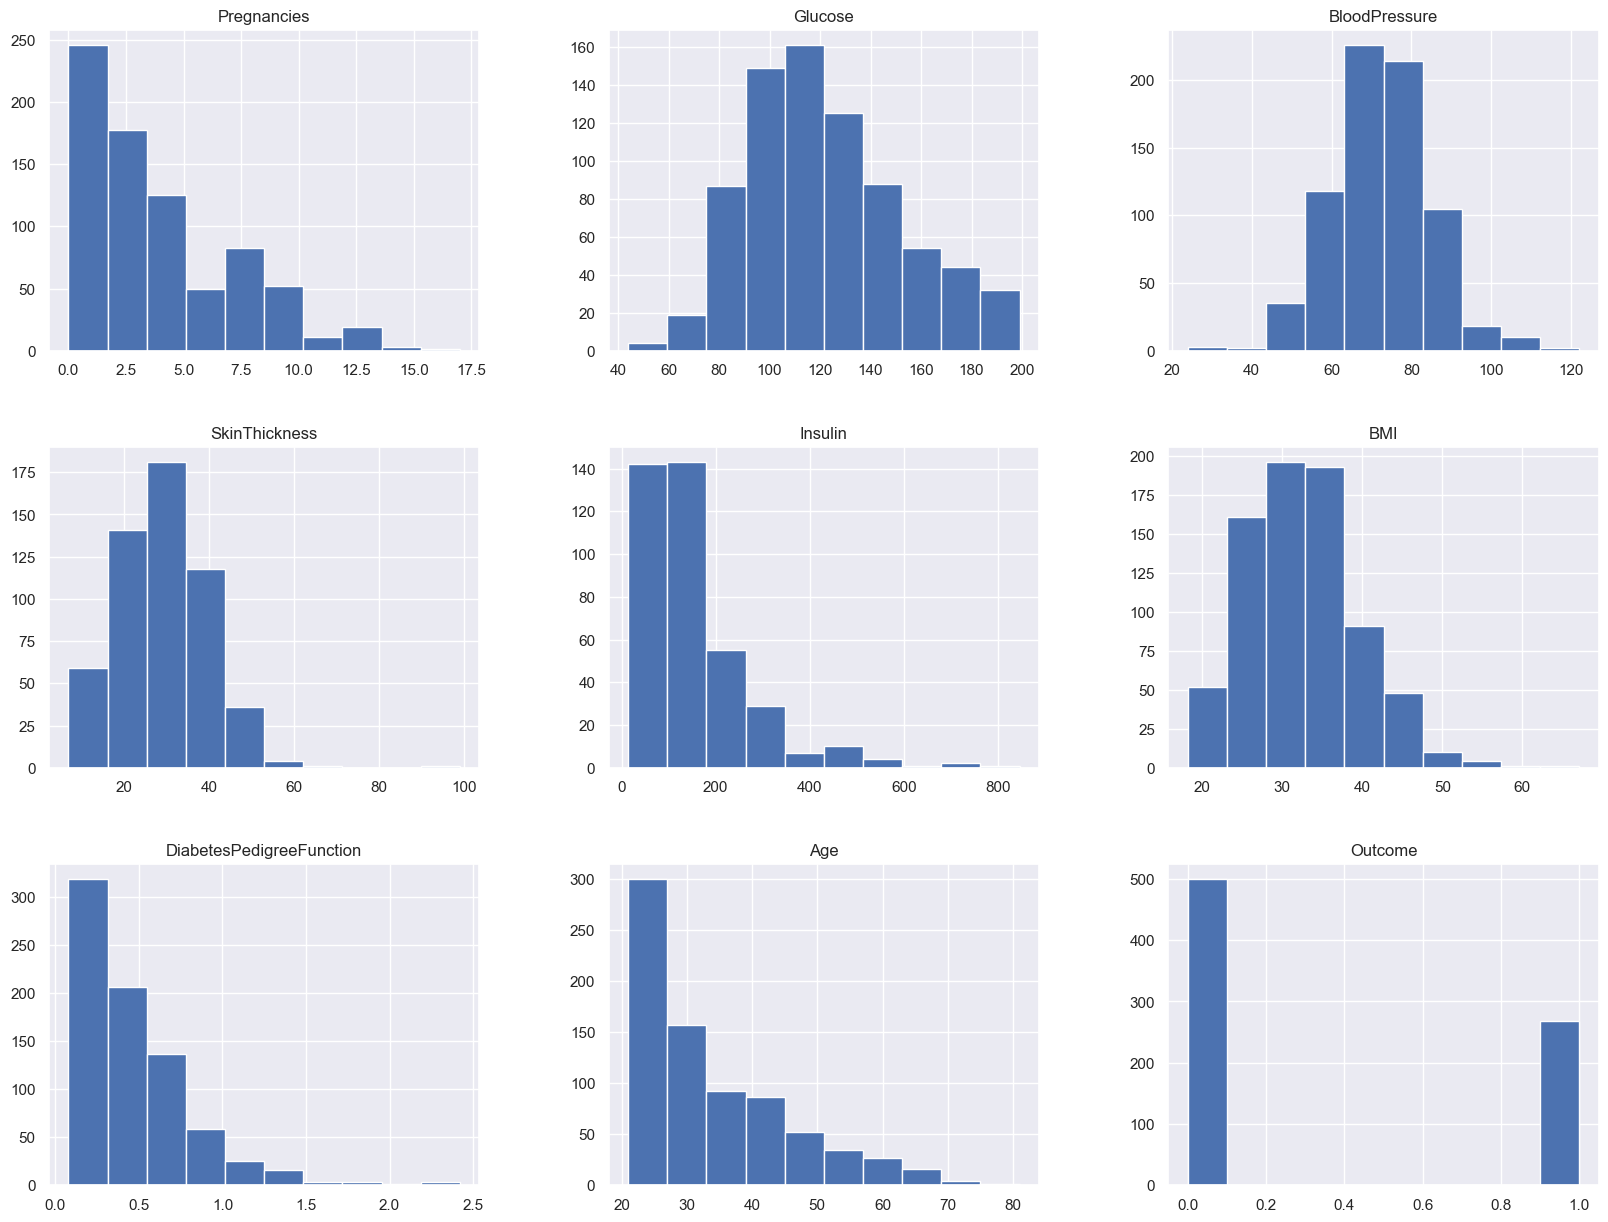

In [207]:
_ = df.hist(bins=10, figsize=(20, 15))


**Class Distribution**

<Axes: >

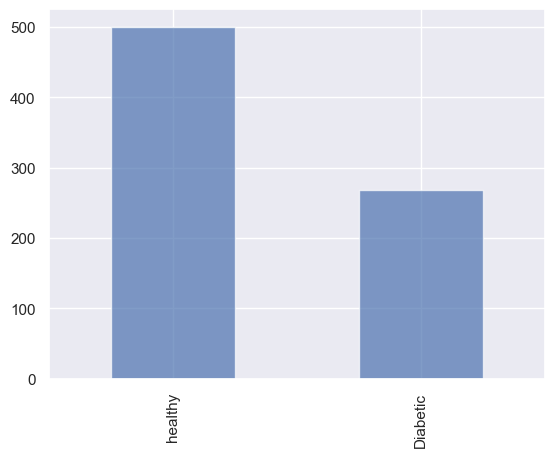

In [208]:
Healthy =  df[ df['Outcome'] == 0 ]
Diabetic = df[ df['Outcome'] == 1 ]

h_diab = pd.Series({'healthy':Healthy.shape[0],
            'Diabetic':Diabetic.shape[0]})
h_diab.plot.bar(alpha=0.7)

**Pie Chart**

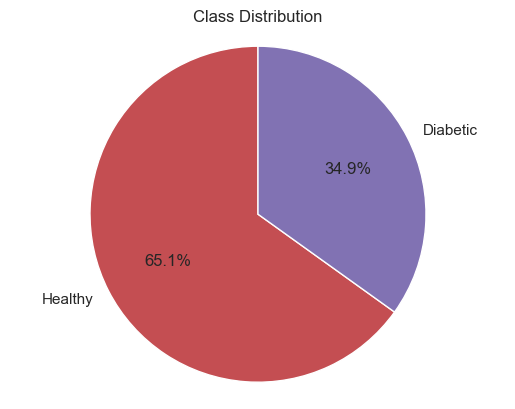

In [209]:
h_diab = pd.Series({
    "Healthy": (df["Outcome"] == 0).sum(),
    "Diabetic": (df["Outcome"] == 1).sum()
})

h_diab.plot.pie(
    labels=h_diab.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["C3", "C4"]
)

plt.title("Class Distribution")
plt.ylabel("")
plt.axis("equal")
plt.show()

**Missing Values**

In [210]:
def replace_null_values(df):

    for col in df.columns:

        df.loc[
            (df.Outcome==0)&(df[col].isnull()),
            col
        ] = df[
            df.Outcome==0
        ][col].median()



        df.loc[
            (df.Outcome==1)&(df[col].isnull()),
            col
        ] = df[
            df.Outcome==1
        ][col].median()



replace_null_values(df)


df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [211]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

**Apply Feature Engineering**

**Label Encoding**

In [212]:
cat_cols=df.select_dtypes(
    include="category"
).columns


df=pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)


df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


**One-Hot Encoding**

**Train/Test Split**

In [213]:
X=df.drop(
    "Outcome",
    axis=1
)


y=df["Outcome"]



X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**# SMOTE**

In [214]:
smote=SMOTE(
    random_state=42
)


X_train,y_train=smote.fit_resample(
    X_train,
    y_train
)


print(y_train.value_counts())

Outcome
0    400
1    400
Name: count, dtype: int64


**Plot Balanced Classes**

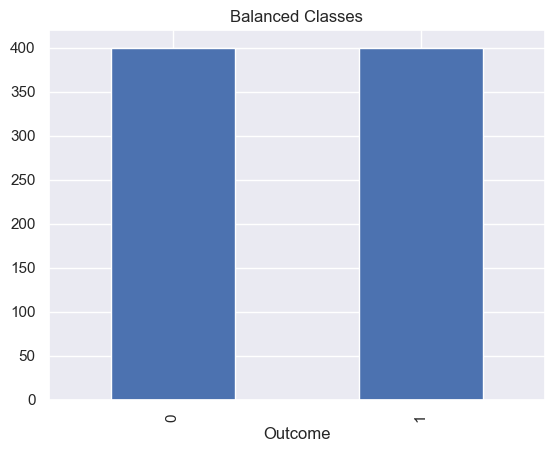

In [215]:
pd.Series(y_train).value_counts().plot.bar()

plt.title("Balanced Classes")
plt.show()

**GridSearchCV**

In [216]:
import mlflow

mlflow.end_run()

In [225]:
import mlflow
from datetime import datetime
from mlflow.tracking import MlflowClient


def create_and_start_run(experiment_name):

    client = MlflowClient()

    # Close previous run if exists
    if mlflow.active_run():
        mlflow.end_run()


    # Find existing experiment
    experiments = client.search_experiments(
        view_type=mlflow.entities.ViewType.ALL
    )


    experiment_id = None


    for exp in experiments:

        if exp.name == experiment_name:

            # Restore if deleted
            if exp.lifecycle_stage == "deleted":
                client.restore_experiment(
                    exp.experiment_id
                )

            experiment_id = exp.experiment_id
            break



    # Create new experiment only if not exists
    if experiment_id is None:

        experiment_id = mlflow.create_experiment(
            experiment_name
        )


    version = datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )


    run_name = (
        f"{experiment_name}_v{version}"
    )


    run = mlflow.start_run(
        experiment_id=experiment_id,
        run_name=run_name
    )


    return run, version

In [226]:
experiment_name="Diabetes-RandomForest-Classification"
run = create_and_start_run(experiment_name)


run,version=create_and_start_run(
    experiment_name
)


with mlflow.active_run():


    params={

        "model":"RandomForest",

        "SMOTE":True,

        "cv":3,

        "scoring":"recall",

        "class_weight":"balanced"

    }


    log_parameters(params)



    rf=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )


    param_grid={

        "n_estimators":[400,500,600],

        "max_leaf_nodes":[14,15,16]

    }


    start=time.time()



    grid=GridSearchCV(
        rf,
        param_grid,
        cv=3,
        scoring="recall"
    )


    grid.fit(
        X_train,
        y_train
    )


    training_time=time.time()-start



    mlflow.log_metric(
        "training_time_sec",
        training_time
    )



    best_rf_model=grid.best_estimator_



    log_parameters(
        grid.best_params_
    )


    mlflow.log_metric(
        "best_cv_recall",
        grid.best_score_
    )


🏃 View run Diabetes-RandomForest-Classification_20260725_091527 at: http://localhost:8004/#/experiments/1/runs/98044d30928742c6b9f75c54ff59fb12
🧪 View experiment at: http://localhost:8004/#/experiments/1
🏃 View run Diabetes-RandomForest-Classification_v20260725_092448 at: http://localhost:8004/#/experiments/1/runs/bdc01e396f104b4ebbfbea9164bd740d
🧪 View experiment at: http://localhost:8004/#/experiments/1
🏃 View run Diabetes-RandomForest-Classification_v20260725_092448 at: http://localhost:8004/#/experiments/1/runs/b8bca4f0c4d94011b9a1cd710b482a17
🧪 View experiment at: http://localhost:8004/#/experiments/1


**Feature Importance**

In [231]:
run, version = create_and_start_run(
    "Diabetes-RandomForest-Classification"
)

🏃 View run merciful-ape-40 at: http://localhost:8004/#/experiments/5/runs/a5e9ea5ad9b74b418310cd9eca291fe3
🧪 View experiment at: http://localhost:8004/#/experiments/5


In [232]:
y_pred=best_rf_model.predict(
    X_test
)


evaluate_model(
    "Diabetes_RandomForest-Classification",
    y_test,
    y_pred,
    best_rf_model
)

Diabetes_RandomForest-Classification
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       100
           1       0.78      0.87      0.82        54

    accuracy                           0.87       154
   macro avg       0.85      0.87      0.86       154
weighted avg       0.88      0.87      0.87       154



{'accuracy': 0.8701298701298701,
 'precision': 0.7833333333333333,
 'recall': 0.8703703703703703,
 'f1_score': 0.8245614035087719,
 'roc_auc': 0.942037037037037}

In [233]:
joblib.dump(
    best_rf_model,
    "models/trained_model.pkl"
)


log_artifact(
    "models/trained_model.pkl"
)


print(
    "Model saved successfully"
)

Model saved successfully


**Save Label Encoder**

In [234]:
mlflow.sklearn.log_model(
    best_rf_model,
    artifact_path="random_forest_model",
    registered_model_name="Diabetes_RandomForest-Classification"
)


print("MLflow completed successfully")

2026/07/25 09:29:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 09:29:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'Diabetes_RandomForest-Classification'.
2026/07/25 09:29:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Diabetes_RandomForest-Classification, version 1


MLflow completed successfully


Created version '1' of model 'Diabetes_RandomForest-Classification'.


**Evaluation**

mlflow.sklearn.log_model(
    best_rf_model,
    artifact_path="random_forest_model",
    registered_model_name="Diabetes_RandomForest"
)


print("MLflow completed successfully")mlflow.sklearn.log_model(
    best_rf_model,
    artifact_path="random_forest_model",
    registered_model_name="Diabetes_RandomForest"
)


print("MLflow completed successfully")### Feature Importance Analysis
Let's analyze the feature importances from the trained Random Forest model to understand which features contribute most to the predictions.